## Import libraries

In [141]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from scipy.signal import butter, filtfilt

## Load data

In [ ]:
user_local_dir = "TODO" # Change this to your local directory

### Load capacitor waveforms

In [289]:
transformer_tap = ["50t", "100t", "150t", "200t"]
cap_data_file_paths = [os.path.join(user_local_dir, f"waveforms/capacitor_waveforms/waveform_{tt}.csv") for tt in transformer_tap]

In [290]:
cap_data_csv = []
for data_file_dir in cap_data_file_paths:
    try:
        df = pd.read_csv(data_file_dir)
        cap_data_csv.append(df)
    except FileNotFoundError:
        # create empty DataFrame with the Voltage (V) column
        print("Empty file")
        empty_df = pd.DataFrame(columns=["Voltage (V)"])
        cap_data_csv.append(empty_df)
        
print(len(cap_data_csv))
cap_data_csv[0].head() 

4


,Time (s),Voltage (V)
0,0.00,1480.0
1,0.04,1580.0
2,0.08,1520.0
3,0.12,1620.0
4,0.16,1540.0


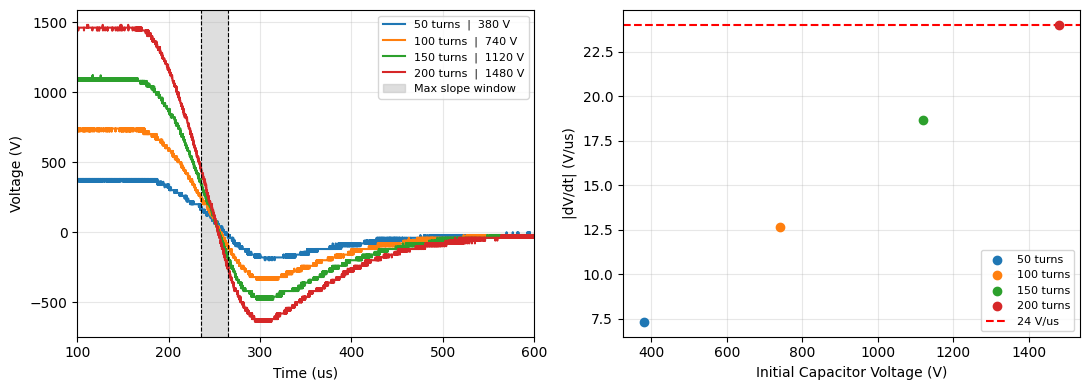

In [291]:
import numpy as np
import matplotlib.pyplot as plt

# CSV time column is labelled seconds but holds microseconds
t = cap_data_csv[0].iloc[5:, 0].to_numpy(dtype=float)   # us
dt = np.median(np.diff(t))

cap_waveforms = np.array([df["Voltage (V)"].to_numpy()[5:] for df in cap_data_csv])
turns = np.array([50, 100, 150, 200])
v0    = cap_waveforms.max(axis=1)          # 380, 740, 1120, 1480 V
LIMIT = 24.0                               # V/us

# Locate the max-slope window for each waveform
WIN_US = 30.0
n = max(2, int(round(WIN_US / dt)))
ref = cap_waveforms[np.argmax(v0)]
excursion = np.array([np.ptp(ref[i:i+n]) for i in range(len(ref) - n)])
i0 = int(excursion.argmax()) + 250
tw = (t[i0], t[i0 + n])
dtw = tw[1] - tw[0]

# Derive dv/dt for each waveform using the max-slope window
dvdt = np.array([np.ptp(w[i0:i0+n]) / dtw for w in cap_waveforms])


# Plot figure
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:4]
fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))

for w, N, V, c in zip(cap_waveforms, turns, v0, colors):
    a.plot(t, w, color=c, label=f"{N} turns  |  {V:.0f} V")
a.axvspan(*tw, color='0.75', alpha=.5, label="Max slope window")
a.axvline(tw[0], color='k', ls='--', lw=.8)
a.axvline(tw[1], color='k', ls='--', lw=.8)
a.set(xlabel="Time (us)", ylabel="Voltage (V)", xlim=(100, 600))
a.legend(fontsize=8); a.grid(alpha=.3)

for V, d, N, c in zip(v0, dvdt, turns, colors):
    b.scatter(V, d, color=c, label=f"{N} turns", zorder=3)
b.axhline(LIMIT, color='red', ls='--', label=f"{LIMIT:.0f} V/us")
b.set(xlabel="Initial Capacitor Voltage (V)", ylabel="|dV/dt| (V/us)")
b.legend(fontsize=8); b.grid(alpha=.3)

plt.tight_layout()
plt.show()

### Load pickup waveforms

In [310]:

rows = ["A", "B", "C", "D", "E", "F", "G", "H"]
data_folder_dir = os.path.join(user_local_dir, f"waveforms/")

homemade_coil = True
low_voltage = True

components = ["x", "y", "z"]
trial_per_component = 3
capacitor_voltage = "24"
component_flips = [-1, -1, 1]
noise_threshold = -np.inf
data_file_paths = [os.path.join(data_folder_dir, f"{component}_component_kapton_{capacitor_voltage}V/waveform_{r}{c}_{i}.csv") for component in components for r in rows for c in range(1, 16) for i in range(1, trial_per_component + 1)]

if not low_voltage:
    components = ["x", "y", "z"]
    trial_per_component = 1
    capacitor_voltage = "1500"
    component_flips = [-1, -1, 1]
    noise_threshold = 0.15
    data_file_paths = [os.path.join(data_folder_dir, f"{component}_component_kapton_{capacitor_voltage}V/waveform_{r}{c}_{i}.csv") for component in components for r in rows for c in range(1, 16) for i in range(1, trial_per_component + 1)]

if not homemade_coil:
    components = ["MagVentureX", "MagVentureY", "MagVentureZ"]
    trial_per_component = 3
    capacitor_voltage = "1500"
    component_flips = [1, -1, -1]
    noise_threshold = 0.15
    data_file_paths = [os.path.join(data_folder_dir, f"{component}_component/waveform_{r}{c}_{i}.csv") for component in components for r in rows for c in range(1, 16) for i in range(1, trial_per_component + 1)]

print(data_file_paths)
print(f"Data file paths: {data_file_paths}")

['/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A1_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A1_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A1_3.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A2_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A2_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A2_3.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A3_1.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A3_2.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_A3_3.csv', '/home/maxence/dev/hardware/TMS/data_processing/waveforms/x_component_kapton_24V/waveform_

In [ ]:
data_csv = []
for data_file_dir in data_file_paths:
    print(f"Reading file: {data_file_dir}")
    try:
        df = pd.read_csv(data_file_dir)
        data_csv.append(df)
    except FileNotFoundError:
        # create empty DataFrame with the Voltage (V) column
        print("Empty file")
        empty_df = pd.DataFrame(columns=["Voltage (V)"])
        data_csv.append(empty_df)
        
print(len(data_csv))
data_csv[0].head() 

## Clean data with low pass filtering

In [312]:
def lowpass(signal, fs, fc, order=4):
    """Zero-phase Butterworth low-pass.
    fs : sample rate [Hz], fc : cutoff [Hz]"""
    nyq = 0.5 * fs
    b, a = butter(order, fc / nyq, btype="low")
    return filtfilt(b, a, signal)

In [313]:
def sample_rate(t):
    dt = np.diff(np.asarray(t))
    return 1.0 / np.mean(dt)

In [ ]:
data_csv_clean = []

fc = 0.12

for data_i in data_csv:
    if not data_i.empty and np.std(data_i["Voltage (V)"]) > noise_threshold:
        fs = sample_rate(data_i["Time (s)"][5:])
        data_i["Voltage (V)"] = lowpass(data_i["Voltage (V)"], fs, fc)
        data_csv_clean.append(data_i[50:])
    else:
        empty_df = pd.DataFrame(columns=["Voltage (V)"])
        data_csv_clean.append(empty_df)

In [315]:
data_csv = data_csv_clean

## Plot Rx Voltage Map

In [316]:
from matplotlib.patches import Circle, Ellipse

# Grid geometry — the two wing centres are 7.5 cells apart, and the B91 wings
# are 2 x 0.0395 m apart, so the implied pitch is 0.079/7.5.
X_LEFT, X_RIGHT, Y_CENTER = 3.25, 10.75, 3.5
PITCH = (2 * 0.0395) / (X_RIGHT - X_LEFT)

_STYLE = dict(fill=False, color='black', linewidth=1, linestyle='--')


def draw_homemade_outline(ax, r_out=3.75, r_in=2.0, **kw):
    style = {**_STYLE, **kw}
    for cx in (X_LEFT, X_RIGHT):
        for r in (r_in, r_out):
            ax.add_artist(Circle((cx, Y_CENTER), r, **style))


def draw_b91_outline(ax, r_in_x=0.0175, r_in_y=0.026,
                     r_out_x=0.0395, r_out_y=0.046,
                     pitch=PITCH, **kw):
    style = {**_STYLE, **kw}
    for cx in (X_LEFT, X_RIGHT):
        for rx, ry in ((r_in_x, r_in_y), (r_out_x, r_out_y)):
            ax.add_artist(Ellipse((cx, Y_CENTER),
                                  width=2 * rx / pitch,
                                  height=2 * ry / pitch, **style))

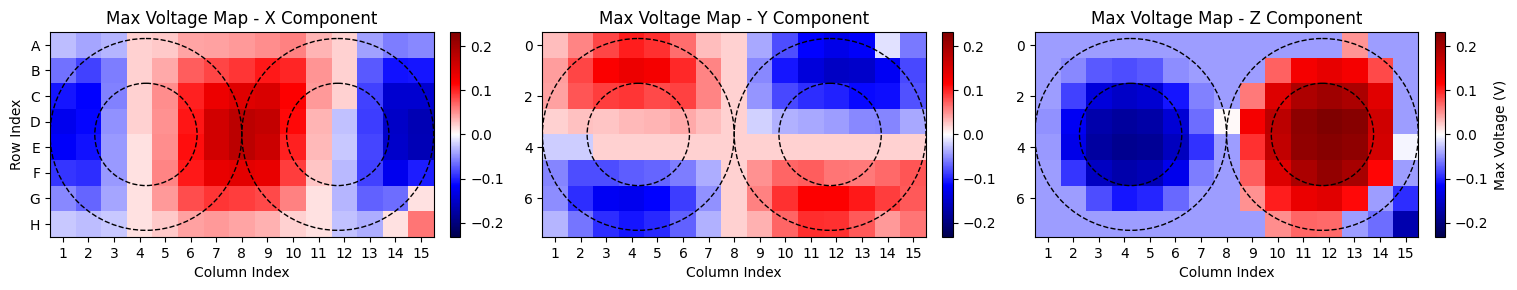

In [330]:
max_voltages = []
for i in range(len(data_csv)):
    if data_csv[i].empty:
        max_voltages.append(np.nan)
    else:
        v = data_csv[i]['Voltage (V)'].to_numpy()[5:]
        max_voltages.append(v[np.argmax(np.abs(v))])


max_voltages = np.array(max_voltages).reshape(3, 8, 15, trial_per_component)
max_voltages_mean = max_voltages.mean(axis=3)

# Flip the voltages to compensate for coil orientation
max_voltages_mean[0] = component_flips[0] * max_voltages_mean[0]
max_voltages_mean[1] = component_flips[1] * max_voltages_mean[1]
max_voltages_mean[2] = component_flips[2] * max_voltages_mean[2]

absolute_max = np.nanmax(np.abs(max_voltages_mean))

draw_outline = draw_homemade_outline if homemade_coil else draw_b91_outline

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, component in enumerate(components):
    axes[i].imshow(max_voltages_mean[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max)
    axes[i].set_title(f'Max Voltage Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(max_voltages_mean[i], cmap='seismic', vmin=-absolute_max, vmax=absolute_max), ax=axes[i], fraction=0.025, pad=0.04)

    draw_outline(axes[i])

cbar.set_label('Max Voltage (V)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

## Plot B-field Map

In [318]:
# We used a 1cm diameter self wounded coil.
area = np.pi * (0.01 / 2) ** 2 # in m^2
print(f"Area of Rx coil: {area} m^2")

N_turns = 10

NAeff = N_turns * area
print(f"N*A of Rx coil: {NAeff} m^2")

Area of Rx coil: 7.853981633974483e-05 m^2
N*A of Rx coil: 0.0007853981633974482 m^2


In [319]:
max_b_field = -max_voltages_mean / NAeff
dB_dt_emperical = max_b_field # save for later use in dI/dt estimation

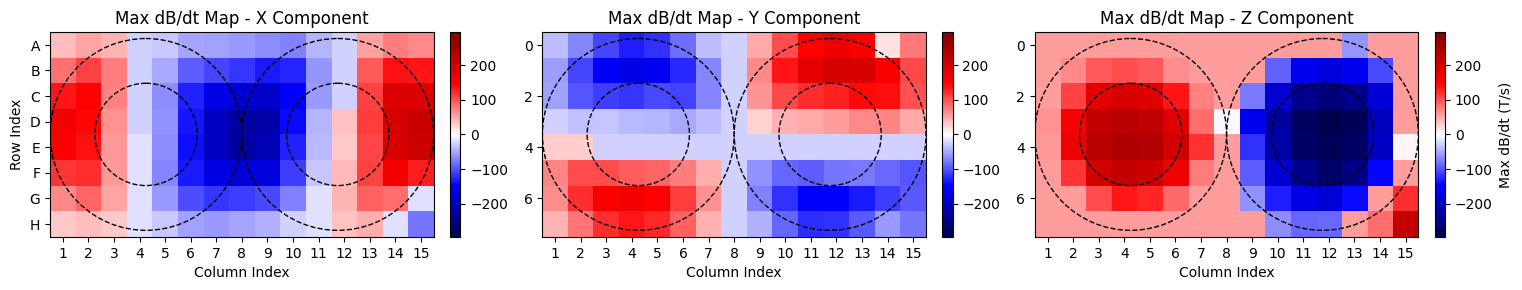

In [320]:

absolute_max_emp = np.nanmax(np.abs(max_b_field))

draw_outline = draw_homemade_outline if homemade_coil else draw_b91_outline


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, component in enumerate(components):
    axes[i].imshow(max_b_field[i], cmap='seismic', vmin=-absolute_max_emp, vmax=absolute_max_emp)
    axes[i].set_title(f'Max dB/dt Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(max_b_field[i], cmap='seismic', vmin=-absolute_max_emp, vmax=absolute_max_emp), ax=axes[i], fraction=0.025, pad=0.04)

    draw_outline(axes[i])

cbar.set_label('Max dB/dt (T/s)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

## Derive coil dI/dt

### Generate model coil

In [321]:
import numpy as np

def generate_tms_coil_segments(n_turns=5, r_in=0.02, r_out=0.0375, layer_gap=0.003, wing_offset=0.038, n_pts_per_loop=72):
    """
    Generates 3D wire segments for a 20-loop stacked figure-8 TMS coil.
    """
    radii = np.linspace(r_in, r_out, n_turns)
    segments_start = []
    segments_end = []
    
    # Layers: z = 0 (bottom), z = layer_gap (top)
    layers = [0.0, layer_gap]
    
    # Wings: left (negative x), right (positive x)
    wings = [('left', -1), ('right', 1)]
    
    for z in layers:
        for side, x_sign in wings:
            center_x = x_sign * wing_offset
            
            # Left wing is counter-clockwise (1), Right wing is clockwise (-1)
            direction = 1 if side == 'left' else -1
            
            for r in radii:
                # Generate angles for the circle
                theta = np.linspace(0, 2 * np.pi, n_pts_per_loop)
                if direction == -1:
                    theta = theta[::-1]
                    
                x = center_x + r * np.cos(theta)
                y = r * np.sin(theta)
                
                # Create start and end points for each straight segment
                for i in range(len(theta) - 1):
                    p1 = [x[i], y[i], z]
                    p2 = [x[i+1], y[i+1], z]
                    segments_start.append(p1)
                    segments_end.append(p2)
                    
    return np.array(segments_start), np.array(segments_end)


def generate_mri_b91_segments(n_turns=4, 
                              r_in_x=0.0175, r_in_y=0.026, 
                              r_out_x=0.0395, r_out_y=0.046, 
                              layer_gap=0.005, wing_offset=0.0395, 
                              n_pts_per_loop=72):
    """
    Generates 3D wire segments for the 2-layer, elliptical MagVenture MRI-B91 coil.
    Vertices are generated in a local coil coordinate frame.
    """
    # Interpolate radii independently for the elliptical spirals
    radii_x = np.linspace(r_in_x, r_out_x, n_turns)
    radii_y = np.linspace(r_in_y, r_out_y, n_turns)
    
    segments_start = []
    segments_end = []
    
    # 2 layers for B91
    layers = [0.0, layer_gap]
    
    # Wings: left (negative x), right (positive x)
    wings = [('left', -1), ('right', 1)]
    
    for z in layers:
        for side, x_sign in wings:
            center_x = x_sign * wing_offset
            
            # Left wing is counter-clockwise (1), Right wing is clockwise (-1)
            direction = 1 if side == 'left' else -1
            
            for rx, ry in zip(radii_x, radii_y):
                # Generate angles for the ellipse
                theta = np.linspace(0, 2 * np.pi, n_pts_per_loop)
                if direction == -1:
                    theta = theta[::-1]
                    
                x = center_x + rx * np.cos(theta)
                y = ry * np.sin(theta)
                
                # Create start and end points for each straight segment
                for i in range(len(theta) - 1):
                    p1 = [x[i], y[i], z]
                    p2 = [x[i+1], y[i+1], z]
                    segments_start.append(p1)
                    segments_end.append(p2)
                    
    return np.array(segments_start), np.array(segments_end)


if homemade_coil:
    # Generate the mesh
    starts, ends = generate_tms_coil_segments()
    print(f"Total wire segments generated: {len(starts)}")
else:
    # Generate the B91 mesh
    starts, ends = generate_mri_b91_segments()
    print(f"Total wire segments generated for MRI-B91: {len(starts)}")

Total wire segments generated: 1420


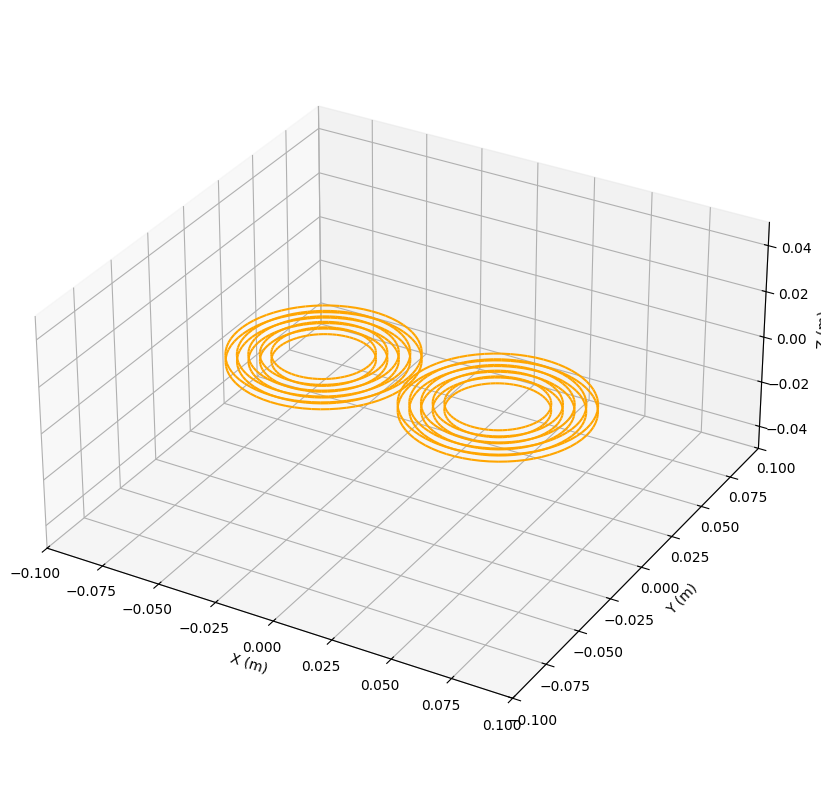

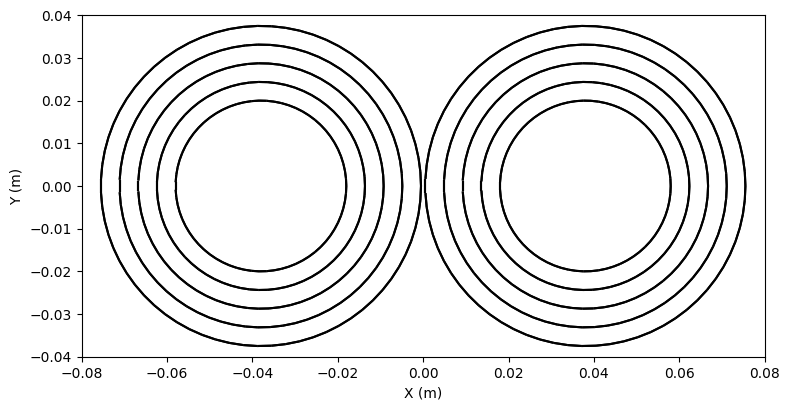

In [322]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.collections import LineCollection
import numpy as np

def visualize_coil_3d(starts, ends):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Pair start and end coordinates for each segment
    segments = [(start, end) for start, end in zip(starts, ends)]
    
    # Add segments to the 3D plot
    lc = Line3DCollection(segments, colors='orange', linewidths=1.5)
    ax.add_collection3d(lc)
    
    # Define spatial boundaries to center the coil
    ax.set_xlim(-0.1, 0.1)
    ax.set_ylim(-0.1, 0.1)
    ax.set_zlim(-0.05, 0.05)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    
    # Force the aspect ratio to maintain physical proportions
    ax.set_box_aspect([1, 1, 0.5])
    
    plt.tight_layout()
    plt.show()


def visualize_coil_2d(starts, ends):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Pair start and end coordinates for each segment
    segments = [(start[:2], end[:2]) for start, end in zip(starts, ends)]
    
    # Add segments to the 2D plot
    lc = LineCollection(segments, colors='black', linewidths=1.5)
    ax.add_collection(lc)
    
    # Define spatial boundaries to center the coil
    ax.set_xlim(-0.08, 0.08)
    ax.set_ylim(-0.04, 0.04)
    
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    
    ax.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# Execute visualization using previously generated arrays
visualize_coil_3d(starts, ends)

visualize_coil_2d(starts, ends)

In [323]:

def compute_dB_dt(starts, ends, target_points, dI_dt=1.0):
    """
    Computes the time derivative of the magnetic field (dB/dt)
    at target points for a given dI/dt using discrete wire segments.
    """
    mu_0 = 4 * np.pi * 1e-7
    
    # Calculate segment vectors and midpoints
    dl = ends - starts
    midpoints = (starts + ends) / 2.0
    
    # Initialize output array
    dB_dt = np.zeros_like(target_points, dtype=float)
    
    # Iterate over target points
    for i, point in enumerate(target_points):
        # Calculate distance vectors from segment midpoints to the target point
        r_vec = point - midpoints
        r_mag = np.linalg.norm(r_vec, axis=1)[:, np.newaxis]
        
        # Prevent division by zero
        r_mag[r_mag == 0] = 1e-10 
        
        # Calculate cross product dl x r_vec
        cross_prod = np.cross(dl, r_vec)
        
        # Calculate dB/dt contribution from each segment
        integrand = cross_prod / (r_mag**3)
        dB_dt[i] = (mu_0 / (4 * np.pi)) * dI_dt * np.sum(integrand, axis=0)
        
    return dB_dt

# Generate 15x8 cm grid with 1 cm spacing
x_vals = np.linspace(-0.075, 0.075, 15) # go from left to right
y_vals = np.linspace(0.04, -0.04, 8) # go from top to bottom (y decreases as we go down)
grid_x, grid_y = np.meshgrid(x_vals, y_vals)

# Position grid 1.5 cm below the coil (z = -0.015)
# Note this is center of pickup coil to bottom of TMS coil, not coil to coil distance. We need to account for the dimensions of the coil and casing.
# Die + Plexiglass (15.7 mm). Pickup coil radius 5 mm, so we are 10.7 mm from the bottom of the coil to the top of the pickup coil.
# For DIY coil: case thickness (0.706 mm), radius of coil (1.294 mm) => Total = 10.7 + 0.706 + 1.294 = 12.7 mm
# For B91 coil: case thickness (6 mm), radius of coil (2.335 mm), additional spacing for cone handle on plexiglass (1mm) => Total = 10.7 + 6 + 2.335 + 1 = 19.035 mm

if homemade_coil:
    grid_z = np.full_like(grid_x, -0.0127) # 12.7 mm below the coil
else:
    grid_z = np.full_like(grid_x, -0.019035) # 19.035 mm below the coil

# Flatten grid into a list of [x, y, z] coordinates
target_pts = np.column_stack((grid_x.ravel(), grid_y.ravel(), grid_z.ravel()))

# Compute field. #115.65 MA/s calculated at 1470V
di_dt_initial_guess = 1.76e6 if low_voltage else 110.86e6 if homemade_coil else 103.89e6 # 1.5 MA/s for TMS pulse
dB_dt_values = compute_dB_dt(starts, ends, target_pts, dI_dt=di_dt_initial_guess)

# Extract components
dBx_dt, dBy_dt, dBz_dt = dB_dt_values.reshape(grid_x.shape[0], grid_x.shape[1], 3).transpose(2, 0, 1)
dB_dt_mag = np.linalg.norm(dB_dt_values, axis=1).reshape(grid_x.shape)

dB_dt_model = np.stack((dBx_dt, dBy_dt, dBz_dt), axis=0)

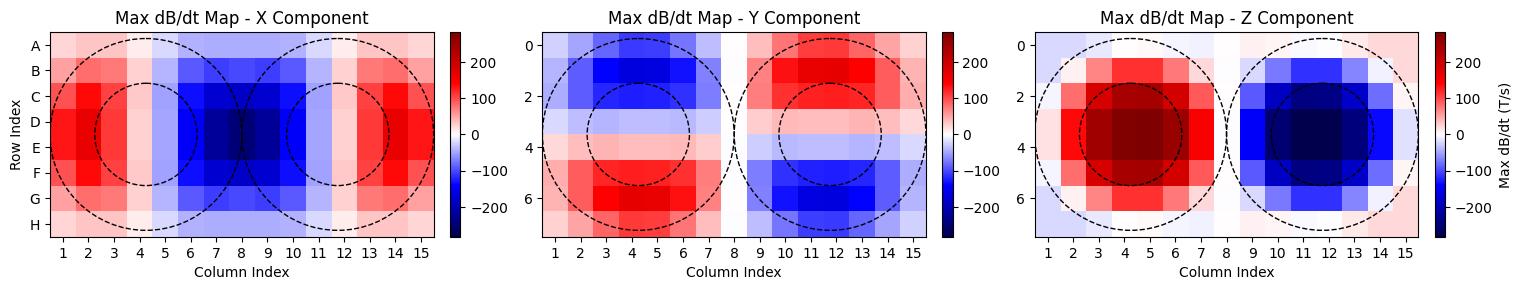

In [324]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

absolute_max_model = np.max(np.abs(dB_dt_model))

draw_outline = draw_homemade_outline if homemade_coil else draw_b91_outline


components = ['x', 'y', 'z']
for i, component in enumerate(components):
    axes[i].imshow(dB_dt_model[i], cmap='seismic', vmin=-absolute_max_model, vmax=absolute_max_model, origin="upper")
    axes[i].set_title(f'Max dB/dt Map - {component.capitalize()} Component')
    axes[i].set_xlabel('Column Index')
    axes[i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    
    # add colorbar
    cbar = plt.colorbar(axes[i].imshow(dB_dt_model[i], cmap='seismic', vmin=-absolute_max_model, vmax=absolute_max_model), ax=axes[i], fraction=0.025, pad=0.04)

    draw_outline(axes[i])

cbar.set_label('Max dB/dt (T/s)')

axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
axes[0].set_ylabel('Row Index')

plt.show()

### Empirical vs Model Comparison

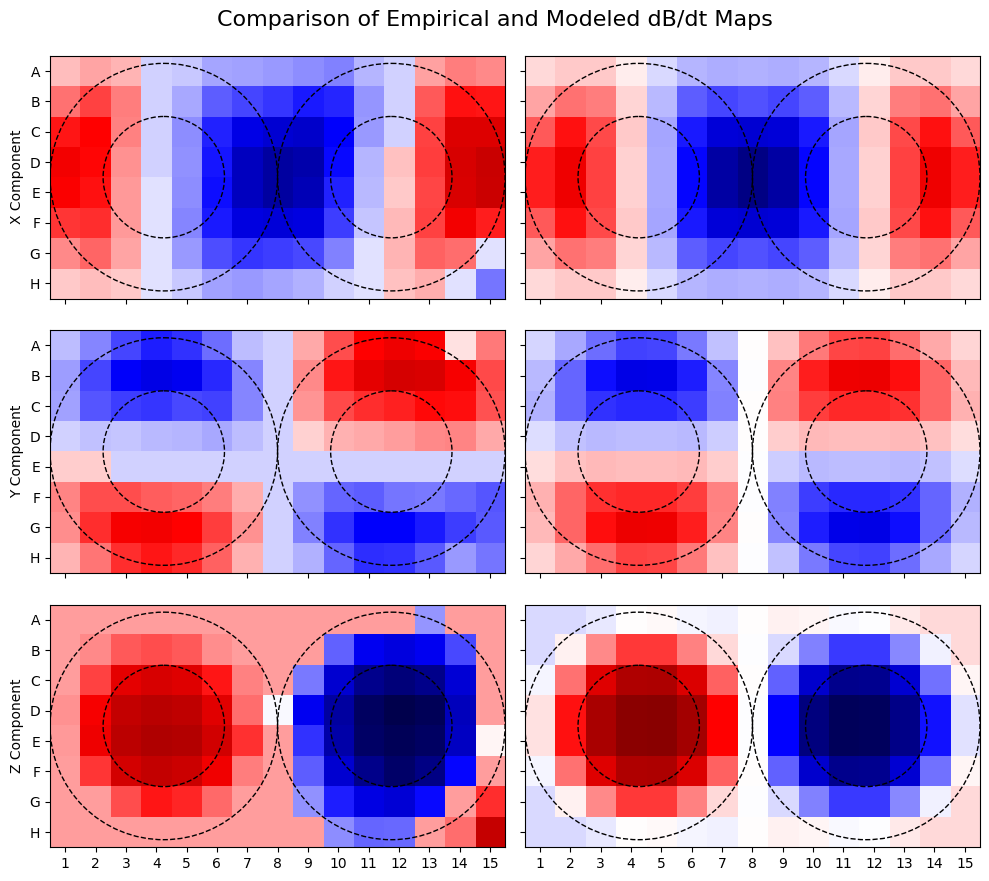

In [325]:

fig, axes = plt.subplots(3, 2, figsize=(10, 9))

absolute_max = np.max([absolute_max_emp, absolute_max_model])

draw_outline = draw_homemade_outline if homemade_coil else draw_b91_outline

components = ['x', 'y', 'z']
for i, data in enumerate([max_b_field, dB_dt_model]):
    for j, component in enumerate(components):
        axes[j, i].imshow(data[j], cmap='seismic', vmin=-absolute_max, vmax=absolute_max, origin="upper")

        axes[j, i].set_xticklabels([])
        axes[j, i].set_yticklabels([])

        if j == 2:
            axes[j, i].set_xticks(ticks=np.arange(15), labels=np.arange(1, 16))    

        if i == 0:
            axes[j, i].set_yticks(ticks=np.arange(len(rows)), labels=rows)
            axes[j, i].set_yticklabels(["A", "B", "C", "D", "E", "F", "G", "H"])

            axes[j, i].set_ylabel(f'{component.capitalize()} Component')

        # Add dot for high voltage points of interest
        #if j == 0 and i == 0:
        #    axes[j, i].scatter([i for i in range(0, 15)] * 2, [3] * 15 + [4] * 15, color='black', s=15, marker='o')
        #if j == 1 and i == 0:
        #    axes[j, i].scatter([3] * 8 + [4] * 8 + [10] * 8 + [11] * 8, [i for i in range(8)] * 4, color='black', s=15, marker='o')
        #if j == 2 and i == 0:
        #    axes[j, i].scatter([i for i in range(0, 15)] * 2, [3] * 15 + [4] * 15, color='black', s=15, marker='o')

        draw_outline(axes[j, i])

cbar.set_label('Max dB/dt (T/s)')

#axes[0].set_yticks(ticks=np.arange(len(rows)), labels=rows)
#axes[0].set_ylabel('Row Index')

plt.suptitle('Comparison of Empirical and Modeled dB/dt Maps', fontsize=16)

plt.tight_layout()
plt.show()

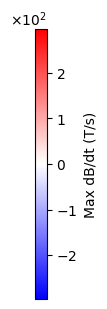

In [326]:
# Create colorbar for the last plot
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
fig = plt.figure(figsize=(0.2, 3))
norm = Normalize(vmin=-absolute_max, vmax=absolute_max)
mappable = ScalarMappable(norm=norm, cmap='bwr')
mappable.set_array([])
cax = fig.add_axes([0.15, 0.05, 0.6, 0.9])
cbar = fig.colorbar(mappable, cax=cax, orientation='vertical')
cbar.set_label('Max dB/dt (T/s)')
ax = plt.gca()
ax.ticklabel_format(axis='both', style='sci', scilimits=(0, 0), useMathText=True)
plt.show()


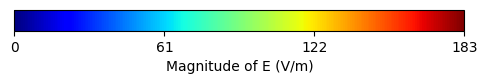

In [327]:
# Create horizontal colorbar for SimNIBS plots
fig = plt.figure(figsize=(5, 0.3))
norm = Normalize(vmin=0, vmax=183)
# Make sure extremums are displayed in the colorbar ticks
mappable = ScalarMappable(norm=norm, cmap='jet')
mappable.set_array([])
cax = fig.add_axes([0.05, 0.15, 0.9, 0.7])
cbar = fig.colorbar(mappable, cax=cax, orientation='horizontal')
cbar.set_ticks(np.arange(0, 184, 61))
cbar.set_label('Magnitude of E (V/m)')
plt.show()

## Derive dI/dt from linear regression

In [328]:
def calculate_current_derivative(emp_dB_dt, mod_dB_dt):
    """
    Calculates the true dI/dt scalar using a linear least-squares fit.
    
    Parameters:
    emp_dB_dt : numpy array of measured dB/dt values (N_points, 3).
    mod_dB_dt : numpy array of modeled dB/dt values (N_points, 3).
    """
    
    # Flatten the arrays to 1D vectors for a global least-squares fit
    emp_vector = emp_dB_dt.ravel()
    mod_vector = mod_dB_dt.ravel()

    # Keep only valid (non-NaN) entries
    valid_mask = ~np.isnan(emp_vector) & ~np.isnan(mod_vector)
    emp_vector = emp_vector[valid_mask]
    mod_vector = mod_vector[valid_mask]
    
    # Compute the dot products
    numerator = np.dot(emp_vector, mod_vector)
    denominator = np.dot(mod_vector, mod_vector)
    
    # Check for zero division
    if denominator == 0:
        return 0.0
        
    # Calculate the optimal scalar
    dI_dt = numerator / denominator
    
    return dI_dt


k = calculate_current_derivative(dB_dt_emperical, dB_dt_model)
dI_dt_val = k * di_dt_initial_guess
print(f"Estimated dI/dt: {dI_dt_val*1e-6:.2f} MA/s")

Estimated dI/dt: 1.76 MA/s


R^2 of linear fit: 0.8889


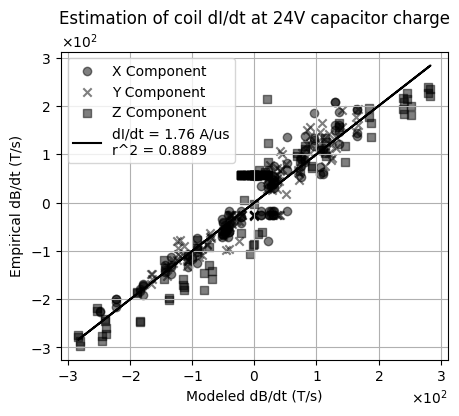

In [329]:
# Plot linear correlation between empirical and modeled dB/dt values
emp_vector = dB_dt_emperical.ravel()
mod_vector = dB_dt_model.ravel()

# Keep only valid (non-NaN) entries
valid_mask = ~np.isnan(emp_vector) & ~np.isnan(mod_vector)
emp_vector = emp_vector[valid_mask]
mod_vector = mod_vector[valid_mask]

r2 = np.corrcoef(emp_vector, mod_vector)[0, 1] ** 2
print(f"R^2 of linear fit: {r2:.4f}")

plt.figure(figsize=(5, 4))
if low_voltage: # more data points
    plt.scatter(mod_vector[0:120], emp_vector[0:120], color="black", marker="o", alpha=0.5, label="X Component")
    plt.scatter(mod_vector[120:240], emp_vector[120:240], color="k", marker="x", alpha=0.5, label="Y Component")
    plt.scatter(mod_vector[240:360], emp_vector[240:360], color="k", marker="s", alpha=0.5, label="Z Component")
else:
    plt.scatter(mod_vector[0:30], emp_vector[0:30], color="black", marker="o", alpha=0.5, label="X Component")
    plt.scatter(mod_vector[30:62], emp_vector[30:62], color="k", marker="x", alpha=0.5, label="Y Component")
    plt.scatter(mod_vector[62:92], emp_vector[62:92], color="k", marker="s", alpha=0.5, label="Z Component")

plt.plot(mod_vector, k * mod_vector, color='black', label=f'dI/dt = {dI_dt_val*1e-6:.2f} A/us\nr^2 = {r2:.4f}')
plt.xlabel('Modeled dB/dt (T/s)')
plt.ylabel('Empirical dB/dt (T/s)')
plt.title('Estimation of coil dI/dt at 24V capacitor charge')
ax = plt.gca()
ax.ticklabel_format(axis='both', style='sci', scilimits=(0, 0), useMathText=True)
plt.legend()
plt.grid()
plt.show()
